# Notebook 15 — 1D CNN Deep Learning Baseline

### Subject-Wise 5-Fold CV | Raw ECG + Resp Signals | Binary Stress Classification

**Architecture decisions based on your exact data:**

- Input: `[batch, 2, 42000]` — 2 channels (ECG ch0, Resp ch1), 42 000 samples per window (700 Hz × 60 s)
- Strided convolutions reduce 42 000 → ~10 tokens before the classifier
- Binary label: `Label == 2 → 1 (Stress)`, all other labels → `0 (Non-Stress)` — matches notebook 11
- Same subject-wise KFold(n_splits=5) as notebook 14 — zero subject leakage
- Normalisation: per-channel z-score fitted on **train windows only** inside each fold


## Cell 1 — Imports & device check

> Run this first. If PyTorch is missing: `pip install torch torchvision torchaudio`


In [1]:
print("Hello DL")

Hello DL


In [2]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
)

os.makedirs("../results/tables",  exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device selected : {device}")
print("Imports OK")

PyTorch version : 2.10.0+cpu
Device selected : cpu
Imports OK


## Cell 2 — Constants

> Must match notebook 02 exactly.


In [4]:
# ── Must match notebook 02 exactly ──────────────────────────────────────────
FS              = 700          # Hz — chest sensor sampling rate
WINDOW_DURATION = 60           # seconds
WINDOW_SIZE     = FS * WINDOW_DURATION   # = 42 000 samples
VALID_LABELS    = [1, 2, 3]    # 1=Baseline, 2=Stress, 3=Relaxed

DATA_DIR = "../data/raw/WESAD"

print(f"Window size : {WINDOW_SIZE:,} samples  ({WINDOW_DURATION}s × {FS}Hz)")
print(f"Data dir    : {DATA_DIR}")

Window size : 42,000 samples  (60s × 700Hz)
Data dir    : ../data/raw/WESAD


## Cell 3 — Windowing function (same logic as notebook 02, saves raw arrays)


In [5]:
# ── Same windowing logic as notebook 02 ─────────────────────────────────────
# Difference: instead of extracting features we KEEP the raw ECG + Resp arrays

def create_raw_windows(ecg, resp, labels, window_size):
    """
    Returns:
        windows : list of np.ndarray, each shape (2, window_size)
                  channel 0 = ECG, channel 1 = Resp
        win_labels : list of int, majority label per window
    """
    windows    = []
    win_labels = []

    for start in range(0, len(ecg) - window_size, window_size):
        end           = start + window_size
        label_segment = labels[start:end]
        label_segment = label_segment[label_segment != 0]   # drop undefined

        if len(label_segment) == 0:
            continue

        label = int(np.bincount(label_segment).argmax())
        if label not in VALID_LABELS:
            continue

        windows.append(np.stack([ecg[start:end],
                                 resp[start:end]], axis=0))  # (2, 42000)
        win_labels.append(label)

    return windows, win_labels

## Cell 4 — Load raw windows for all 15 subjects

> Takes ~30–60 s depending on disk speed. Each PKL is ~500 MB.


In [6]:
# ── Load raw PKL files and window each subject ──────────────────────────────
subjects_found = sorted([s for s in os.listdir(DATA_DIR) if s.startswith("S")])

all_windows     = []   # list of (2, 42000) arrays
all_labels_raw  = []   # original 1/2/3 labels
all_subject_ids = []   # subject string e.g. "S10"

for subject in subjects_found:
    pkl_path = os.path.join(DATA_DIR, subject, f"{subject}.pkl")
    if not os.path.isfile(pkl_path):
        print(f"{subject}: pkl not found, skipping")
        continue

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest  = data["signal"]["chest"]
    ecg    = chest["ECG"].flatten()
    resp   = chest["Resp"].flatten()
    labels = data["label"].flatten()

    wins, win_labels = create_raw_windows(ecg, resp, labels, WINDOW_SIZE)

    all_windows.extend(wins)
    all_labels_raw.extend(win_labels)
    all_subject_ids.extend([subject] * len(wins))

    print(f"  {subject}: {len(wins)} windows")

print(f"\nTotal windows loaded : {len(all_windows)}")
print(f"Expected             : ~599  (matches notebook 02)")

  S10: 41 windows
  S11: 41 windows
  S13: 41 windows
  S14: 40 windows
  S15: 41 windows
  S16: 40 windows
  S17: 41 windows
  S2: 39 windows
  S3: 39 windows
  S4: 38 windows
  S5: 39 windows
  S6: 40 windows
  S7: 40 windows
  S8: 41 windows
  S9: 38 windows

Total windows loaded : 599
Expected             : ~599  (matches notebook 02)


## Cell 5 — Convert to binary labels

> Same rule as notebook 11: `Label == 2 → 1 (Stress)`, everything else → `0`


In [7]:
# ── Binary encoding — matches notebook 11 logic ─────────────────────────────
# Label 2 = Stress → 1,  Label 1 (Baseline) + Label 3 (Relaxed) → 0

signals      = np.stack(all_windows, axis=0)           # (N, 2, 42000)
labels_binary = np.array([1 if l == 2 else 0
                           for l in all_labels_raw])    # (N,)
subject_ids  = np.array(all_subject_ids)                # (N,)

print(f"signals shape     : {signals.shape}   — (N_windows, channels, samples)")
print(f"labels shape      : {labels_binary.shape}")
print(f"Unique labels     : {np.unique(labels_binary)}  (0=Non-Stress, 1=Stress)")
print(f"Stress windows    : {labels_binary.sum()}  ({labels_binary.mean()*100:.1f}%)")
print(f"Non-Stress windows: {(1-labels_binary).sum()}  ({(1-labels_binary).mean()*100:.1f}%)")
print(f"Unique subjects   : {np.unique(subject_ids)}")

signals shape     : (599, 2, 42000)   — (N_windows, channels, samples)
labels shape      : (599,)
Unique labels     : [0 1]  (0=Non-Stress, 1=Stress)
Stress windows    : 182  (30.4%)
Non-Stress windows: 417  (69.6%)
Unique subjects   : ['S10' 'S11' 'S13' 'S14' 'S15' 'S16' 'S17' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7'
 'S8' 'S9']


## Cell 6 — 1D CNN architecture

> Designed for input `(batch, 2, 42000)`. Three strided conv blocks reduce length aggressively before `AdaptiveAvgPool1d`.


In [8]:
# ── 1D CNN — input shape (batch, 2, 42000) ───────────────────────────────────
#
#  Conv block 1: 2  → 32  channels, kernel=16, stride=4  → length ≈ 10 500
#  Conv block 2: 32 → 64  channels, kernel=8,  stride=4  → length ≈  2 625
#  Conv block 3: 64 → 128 channels, kernel=5,  stride=2  → length ≈  1 311
#  AdaptiveAvgPool1d(16)                                  → length =     16
#  FC: 128*16 = 2048 → 128 → 2
#
#  BatchNorm + Dropout prevent overfitting on small N=599

class CNN1D(nn.Module):
    def __init__(self, n_channels=2, n_classes=2, dropout=0.4):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=16, stride=4, padding=6),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=8, stride=4, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool1d(16)   # → fixed (128, 16) regardless of input length

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        return self.classifier(x)


# ── Quick sanity check with a random batch ───────────────────────────────────
test_input = torch.randn(4, 2, 42000)
test_model  = CNN1D()
test_output = test_model(test_input)
print(f"Input shape  : {test_input.shape}")
print(f"Output shape : {test_output.shape}   ← expect (4, 2)")
print(f"Model params : {sum(p.numel() for p in test_model.parameters()):,}")
del test_model, test_input, test_output

Input shape  : torch.Size([4, 2, 42000])
Output shape : torch.Size([4, 2])   ← expect (4, 2)
Model params : 321,570


## Cell 7 — Per-channel normalisation helper

> Fitted on **train windows only** inside each fold — same principle as `StandardScaler` in notebook 14.


In [9]:
# ── Per-channel z-score — fit on train, apply to train+test ─────────────────
# signals shape: (N, 2, 42000)
# We compute mean/std over the time axis (axis=2) then average across windows
# to get one mean and one std per channel.

def channel_normalize(X_train_raw, X_test_raw):
    """
    X_train_raw, X_test_raw: np.ndarray of shape (N, 2, 42000)
    Returns normalised float32 arrays of the same shape.
    """
    # Compute per-channel statistics from TRAIN only
    # mean / std over all time samples across all train windows
    mean = X_train_raw.mean(axis=(0, 2), keepdims=True)   # (1, 2, 1)
    std  = X_train_raw.std(axis=(0, 2),  keepdims=True)   # (1, 2, 1)
    std[std == 0] = 1.0   # guard against flat channels

    X_train_norm = ((X_train_raw - mean) / std).astype(np.float32)
    X_test_norm  = ((X_test_raw  - mean) / std).astype(np.float32)

    return X_train_norm, X_test_norm

print("Normalisation helper defined")

Normalisation helper defined


## Cell 8 — Subject-wise 5-Fold CV Training Loop

> ⏱ Runtime estimate: ~5–15 min on CPU, ~2–3 min on GPU.


In [10]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
EPOCHS      = 25       # increase to 40-50 if you have GPU
BATCH_SIZE  = 16       # small batch — N_train ≈ 480 windows
LR          = 1e-3
DROPOUT     = 0.4

# ── KFold over subjects (same seed as notebook 14) ───────────────────────────
unique_subjects = np.unique(subject_ids)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Metric storage ────────────────────────────────────────────────────────────
cnn_metrics = {"accuracy":[], "precision":[], "recall":[], "f1":[], "roc_auc":[]}
all_y_true, all_y_pred, all_y_prob = [], [], []

# ── Main loop ─────────────────────────────────────────────────────────────────
for fold_idx, (train_subj_idx, test_subj_idx) in enumerate(kf.split(unique_subjects), 1):

    train_subjects = unique_subjects[train_subj_idx]
    test_subjects  = unique_subjects[test_subj_idx]

    train_mask = np.isin(subject_ids, train_subjects)
    test_mask  = np.isin(subject_ids, test_subjects)

    # ── Raw signal arrays for this fold ──────────────────────────────────────
    X_train_raw = signals[train_mask]          # (N_train, 2, 42000)
    X_test_raw  = signals[test_mask]

    y_train_np  = labels_binary[train_mask]    # (N_train,)
    y_test_np   = labels_binary[test_mask]

    # ── Normalise (fit on train only) ────────────────────────────────────────
    X_train_np, X_test_np = channel_normalize(X_train_raw, X_test_raw)

    # ── Tensors + DataLoaders ─────────────────────────────────────────────────
    X_tr = torch.tensor(X_train_np)
    y_tr = torch.tensor(y_train_np, dtype=torch.long)
    X_te = torch.tensor(X_test_np)
    y_te = torch.tensor(y_test_np,  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_te, y_te),
                              batch_size=BATCH_SIZE, shuffle=False)

    # ── Fresh model every fold ────────────────────────────────────────────────
    model     = CNN1D(dropout=DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    print(f"\nFold {fold_idx}/5  |  train subjects: {list(train_subjects)}")
    print(f"           |  test subjects : {list(test_subjects)}")
    print(f"           |  train windows : {len(X_tr)}  |  test windows: {len(X_te)}")

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        if epoch % 5 == 0:
            print(f"    Epoch {epoch:>2}/{EPOCHS}  loss={epoch_loss/len(train_loader):.4f}")

    # ── Evaluation ────────────────────────────────────────────────────────────
    model.eval()
    fold_preds, fold_probs, fold_true = [], [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            logits  = model(batch_x)
            probs   = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds   = logits.argmax(dim=1).cpu().numpy()

            fold_preds.extend(preds)
            fold_probs.extend(probs)
            fold_true.extend(batch_y.numpy())

    # ── Per-fold metrics (stress = positive class = 1) ────────────────────────
    acc  = accuracy_score (fold_true, fold_preds)
    prec = precision_score(fold_true, fold_preds, pos_label=1, zero_division=0)
    rec  = recall_score   (fold_true, fold_preds, pos_label=1, zero_division=0)
    f1   = f1_score       (fold_true, fold_preds, pos_label=1, zero_division=0)
    try:
        roc = roc_auc_score(fold_true, fold_probs)
    except ValueError:
        roc = float("nan")
        print("ROC-AUC undefined for this fold (single class in y_test)")

    cnn_metrics["accuracy"].append(acc)
    cnn_metrics["precision"].append(prec)
    cnn_metrics["recall"].append(rec)
    cnn_metrics["f1"].append(f1)
    cnn_metrics["roc_auc"].append(roc)

    all_y_true.extend(fold_true)
    all_y_pred.extend(fold_preds)
    all_y_prob.extend(fold_probs)

    print(f"    Fold {fold_idx} → Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={roc:.3f}")

print("\n✓ Cross-validation complete")


Fold 1/5  |  train subjects: [np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S2'), np.str_('S3'), np.str_('S5'), np.str_('S7'), np.str_('S8'), np.str_('S9')]
           |  test subjects : [np.str_('S10'), np.str_('S4'), np.str_('S6')]
           |  train windows : 480  |  test windows: 119
    Epoch  5/25  loss=0.3000
    Epoch 10/25  loss=0.2303
    Epoch 15/25  loss=0.1381
    Epoch 20/25  loss=0.0933
    Epoch 25/25  loss=0.0747
    Fold 1 → Acc=0.689  Prec=0.490  Rec=0.694  F1=0.575  AUC=0.780

Fold 2/5  |  train subjects: [np.str_('S10'), np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S17'), np.str_('S2'), np.str_('S4'), np.str_('S5'), np.str_('S6'), np.str_('S7'), np.str_('S9')]
           |  test subjects : [np.str_('S16'), np.str_('S3'), np.str_('S8')]
           |  train windows : 479  |  test windows: 120
    Epoch  5/25  loss=0.3039
    Epoch 10/25  loss=0.1966
    Epoch 15/25  loss=0.1148
 

## Cell 9 — Mean ± Std summary


In [11]:
# ── Aggregate metrics ────────────────────────────────────────────────────────
print("\n" + "="*55)
print("1D CNN — 5-Fold CV Results (mean ± std)")
print("="*55)

summary = {}
for metric, vals in cnn_metrics.items():
    arr = np.array(vals)
    m, s = np.nanmean(arr), np.nanstd(arr)
    summary[metric] = (m, s)
    print(f"  {metric:<12}: {m:.3f} ± {s:.3f}")

print("="*55)

# ── Nicely formatted DataFrame ────────────────────────────────────────────────
cnn_summary_df = pd.DataFrame([{
    "Model"     : "1D CNN (ECG+Resp)",
    "Accuracy"  : f"{summary['accuracy'][0]:.3f} ± {summary['accuracy'][1]:.3f}",
    "Precision" : f"{summary['precision'][0]:.3f} ± {summary['precision'][1]:.3f}",
    "Recall"    : f"{summary['recall'][0]:.3f} ± {summary['recall'][1]:.3f}",
    "F1 Score"  : f"{summary['f1'][0]:.3f} ± {summary['f1'][1]:.3f}",
    "ROC-AUC"   : f"{summary['roc_auc'][0]:.3f} ± {summary['roc_auc'][1]:.3f}",
}])
cnn_summary_df.set_index("Model")


1D CNN — 5-Fold CV Results (mean ± std)
  accuracy    : 0.793 ± 0.084
  precision   : 0.653 ± 0.156
  recall      : 0.779 ± 0.132
  f1          : 0.699 ± 0.115
  roc_auc     : 0.854 ± 0.087


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
1D CNN (ECG+Resp),0.793 ± 0.084,0.653 ± 0.156,0.779 ± 0.132,0.699 ± 0.115,0.854 ± 0.087


## Cell 10 — Aggregated Confusion Matrix (all 5 folds)


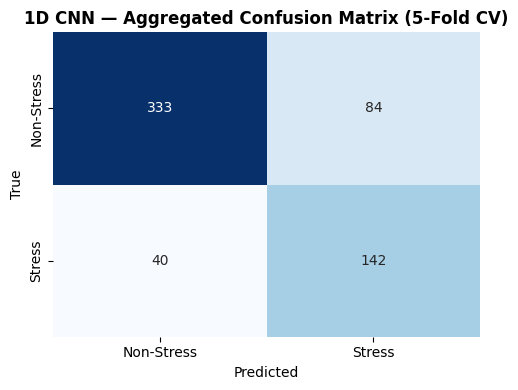

Saved → ../results/figures/cnn_confusion_matrix.png


In [12]:
yt = np.array(all_y_true)
yp = np.array(all_y_pred)
cm = confusion_matrix(yt, yp)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-Stress", "Stress"],
            yticklabels=["Non-Stress", "Stress"],
            cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("1D CNN — Aggregated Confusion Matrix (5-Fold CV)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/cnn_confusion_matrix.png", dpi=300)
plt.show()
print("Saved → ../results/figures/cnn_confusion_matrix.png")

## Cell 11 — Aggregated ROC Curve


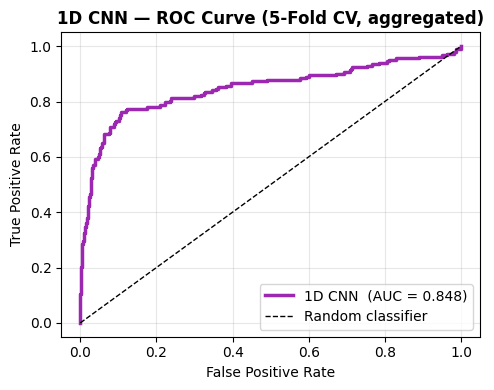

Saved → ../results/figures/cnn_roc_curve.png


In [13]:
ypr = np.array(all_y_prob)
fpr, tpr, _ = roc_curve(yt, ypr)
roc_val     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="#9C27B0", lw=2.5,
        label=f"1D CNN  (AUC = {roc_val:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("1D CNN — ROC Curve (5-Fold CV, aggregated)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/cnn_roc_curve.png", dpi=300)
plt.show()
print("Saved → ../results/figures/cnn_roc_curve.png")

## Cell 12 — Per-fold detail table


In [14]:
detail_rows = []
for i in range(5):
    detail_rows.append({
        "Fold"     : i + 1,
        "Accuracy" : round(cnn_metrics["accuracy"][i],  4),
        "Precision": round(cnn_metrics["precision"][i], 4),
        "Recall"   : round(cnn_metrics["recall"][i],    4),
        "F1"       : round(cnn_metrics["f1"][i],        4),
        "ROC-AUC"  : round(cnn_metrics["roc_auc"][i],   4),
    })

cnn_detail_df = pd.DataFrame(detail_rows)
cnn_detail_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.6891,0.4902,0.6944,0.5747,0.7805
1,2,0.9333,0.9394,0.8378,0.8857,0.9430
2,3,0.7333,0.5370,0.8056,0.6444,0.8757
3,4,0.7815,0.6562,0.5833,0.6176,0.7282
4,5,0.8264,0.6429,0.9730,0.7742,0.9440


## Cell 13 — Save results to CSV


In [15]:
cnn_summary_df.to_csv("../results/tables/cnn_cv_summary.csv", index=False)
cnn_detail_df.to_csv("../results/tables/cnn_cv_per_fold.csv",  index=False)

print("Saved → ../results/tables/cnn_cv_summary.csv")
print("Saved → ../results/tables/cnn_cv_per_fold.csv")

Saved → ../results/tables/cnn_cv_summary.csv
Saved → ../results/tables/cnn_cv_per_fold.csv
